### Import Data

In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import display

release_name = "analysis_release_v1_20261005T194400349609Z"
current_dir = Path.cwd().resolve()

ROOT = next(
    (
        folder
        for folder in [current_dir, *current_dir.parents]
        if (folder / "data/processed" / release_name).is_dir()
    ),
    None,
)

if ROOT is None:
    raise FileNotFoundError("Không tìm thấy release trong project.")

RELEASE_DIR = ROOT / "data" / "processed" / release_name

twitch = pd.read_csv(
    RELEASE_DIR / "twitch_monthly.csv",
    encoding="utf-8-sig",
)

print("Release:", release_name)
print("Số dòng:", len(twitch))
display(twitch.head())

Release: analysis_release_v1_20261005T194400349609Z
Số dòng: 369


,rank,game,month,year,hours_watched,hours_streamed,peak_viewers,peak_channels,streamers,avg_viewers,...,measurement_level,source_category_raw,source_category,source_file,quality_status,game_family,analysis_role,hours_watched_iqr_flag,avg_viewers_iqr_flag,peak_viewers_iqr_flag
0,1,League of Legends,1,2016,94377226,1362044,530270,2903,129172,127021,...,game_month,League of Legends,League of Legends,C:\Users\dthin\Downloads\Twitch_game_data.csv,usable,League of Legends,main,False,False,False
1,2,Counter-Strike: Global Offensive,1,2016,47832863,830105,372654,2197,120849,64378,...,game_month,Counter-Strike: Global Offensive,Counter-Strike: Global Offensive,C:\Users\dthin\Downloads\Twitch_game_data.csv,usable,Counter-Strike,main,False,False,False
2,3,Dota 2,1,2016,45185893,433397,315083,1100,44074,60815,...,game_month,Dota 2,Dota 2,C:\Users\dthin\Downloads\Twitch_game_data.csv,usable,Dota 2,main,False,False,False
3,1,League of Legends,2,2016,93154772,1266715,475784,2712,117996,134035,...,game_month,League of Legends,League of Legends,C:\Users\dthin\Downloads\Twitch_game_data.csv,usable,League of Legends,main,False,False,False
4,2,Counter-Strike: Global Offensive,2,2016,44933218,754901,235027,2097,106074,64652,...,game_month,Counter-Strike: Global Offensive,Counter-Strike: Global Offensive,C:\Users\dthin\Downloads\Twitch_game_data.csv,usable,Counter-Strike,main,False,False,False


### Kiểm tra đầu vào và phạm vi thời gian

In [4]:
twitch["month_start"] = pd.to_datetime(
    twitch["month_start"], format="%Y-%m-%d", errors="raise"
)

metrics = ["hours_watched", "avg_viewers", "peak_viewers"]

for metric in metrics:
    twitch[metric] = pd.to_numeric(twitch[metric], errors='raise')

assert twitch["game_family"].notna().all()
assert twitch["month_start"].notna().all()
assert not twitch.duplicated(["game_family", "month_start"]).any()
assert twitch[metrics].notna().all().all()
assert twitch[metrics].ge(0).all().all()
assert twitch["peak_viewers"].ge(twitch["avg_viewers"]).all()

coverage = twitch.groupby("game_family").agg(
    so_thang=("month_start", "size"),
    thang_dau=("month_start", "min"),
    thang_cuoi=("month_start", "max"),
)

display(coverage)

,so_thang,thang_dau,thang_cuoi
game_family,,,
Counter-Strike,105,2016-01-01,2024-09-01
Dota 2,105,2016-01-01,2024-09-01
League of Legends,105,2016-01-01,2024-09-01
Valorant,54,2020-04-01,2024-09-01


### Chọn khoảng dữ liệu

In [5]:
twitch_common = twitch.loc[
    twitch['month_start'].between("2020-04-01", "2024-09-01")
].copy()

print("Số tháng theo game:")
display(
    twitch_common.groupby("game_family")
    .size()
    .to_frame("Số tháng")
)

assert twitch_common.groupby("game_family").size().eq(54).all(), (
    "Có game không đủ 54 tháng; cần kiểm tra."
)

Số tháng theo game:


,Số tháng
game_family,
Counter-Strike,54
Dota 2,54
League of Legends,54
Valorant,54


In [6]:
twitch_summary = twitch_common.groupby("game_family").agg(
    so_thang=("month_start", "size"),
    tong_gio_xem=("hours_watched", "sum"),
    trung_vi_gio_xem_thang=("hours_watched", "median"),
    trung_vi_avg_viewers=("avg_viewers", "median"),
    peak_viewers_cao_nhat=("peak_viewers", "max"),
)

display(twitch_summary.style.format({
    "so_thang": "{:,.0f}",
    "tong_gio_xem": "{:,.0f}",
    "trung_vi_gio_xem_thang": "{:,.0f}",
    "trung_vi_avg_viewers": "{:,.0f}",
    "peak_viewers_cao_nhat": "{:,.0f}",
}))

,so_thang,tong_gio_xem,trung_vi_gio_xem_thang,trung_vi_avg_viewers,peak_viewers_cao_nhat
game_family,,,,,
Counter-Strike,54,"3,235,617,296","58,609,832","81,154","1,916,027"
Dota 2,54,"2,461,018,828","43,058,622","58,087","1,636,441"
League of Legends,54,"6,790,202,952","125,981,511","169,557","3,145,012"
Valorant,54,"4,631,862,775","83,779,198","112,802","1,728,977"


#### Vẽ xu hướng Twitch

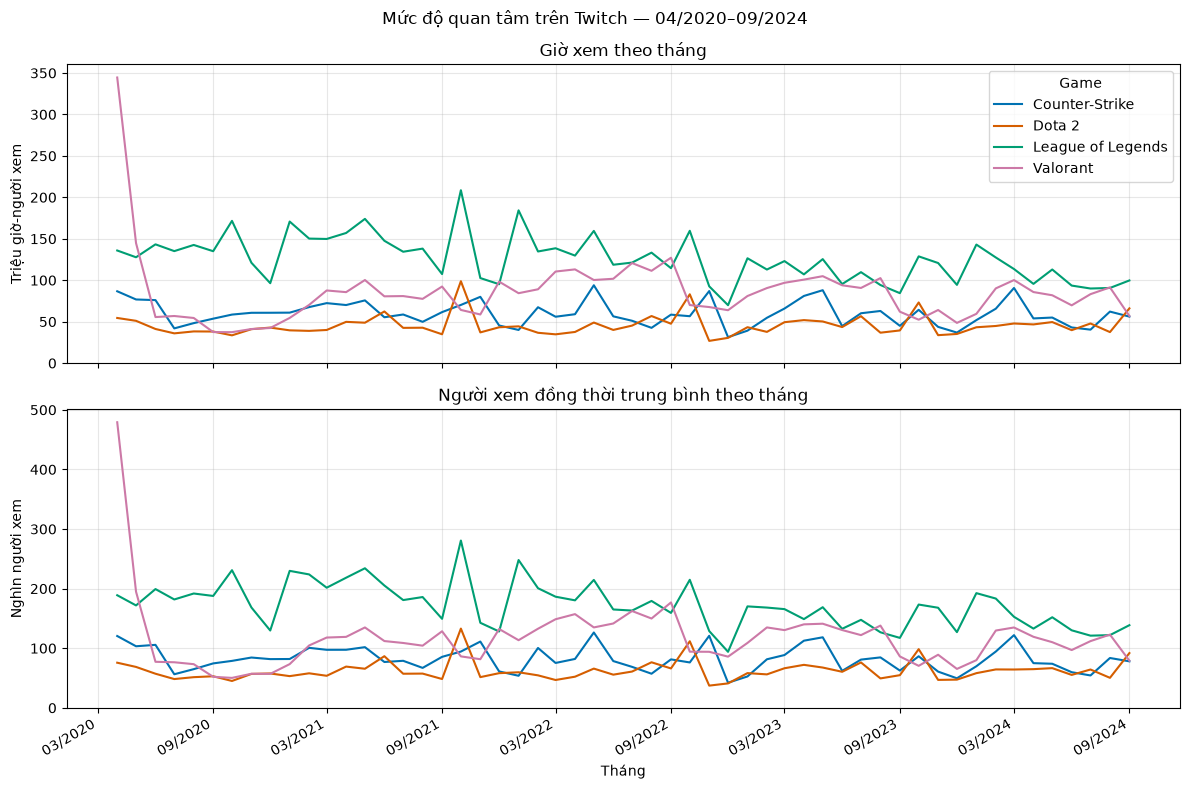

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]
colors = dict(zip(
    games, ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
))

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

for game in games:
    group = twitch_common.loc[
        twitch_common["game_family"].eq(game)
    ].sort_values("month_start")

    axes[0].plot(
        group["month_start"],
        group["hours_watched"] / 1_000_000,
        color=colors[game],
        label=game,
    )

    axes[1].plot(
        group["month_start"],
        group["avg_viewers"] / 1_000,
        color=colors[game],
        label=game,
    )

axes[0].set_title("Giờ xem theo tháng")
axes[0].set_ylabel("Triệu giờ-người xem")
axes[0].legend(title="Game")

axes[1].set_title("Người xem đồng thời trung bình theo tháng")
axes[1].set_ylabel("Nghìn người xem")
axes[1].set_xlabel("Tháng")

axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=6))
axes[1].xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))

for ax in axes:
    ax.grid(alpha=0.3)
    ax.set_ylim(bottom=0)

fig.suptitle("Mức độ quan tâm trên Twitch — 04/2020–09/2024")
fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### Tính tăng trưởng theo tháng

In [14]:

growth = twitch_common.sort_values(
    ["game_family", "month_start"]
).copy()

groups = growth.groupby("game_family")

previous_hours = groups["hours_watched"].shift()
previous_month = groups["month_start"].shift()

# Chỉ so sánh hai tháng liên tiếp và mẫu số lớn hơn 0.
current_period = growth["month_start"].dt.to_period("M")
previous_period = previous_month.dt.to_period("M")
consecutive = current_period.eq(previous_period + 1)

growth["hours_watched_mom_pct"] = (
    (growth["hours_watched"] / previous_hours.where(previous_hours.gt(0)) - 1)
    * 100
).where(consecutive)

display(growth[[
    "game_family", "month_start",
    "hours_watched", "hours_watched_mom_pct",
]].head())

,game_family,month_start,hours_watched,hours_watched_mom_pct
154,Counter-Strike,2020-04-01,86673161,NaN
158,Counter-Strike,2020-05-01,76786808,-11.406476
162,Counter-Strike,2020-06-01,76001332,-1.022931
167,Counter-Strike,2020-07-01,41902442,-44.866174
172,Counter-Strike,2020-08-01,48243344,15.132536


### Nhận diện tháng bùng nổ theo tiêu chí rõ ràng

In [15]:
groups = growth.groupby("game_family")["hours_watched"]
q1 = groups.transform(lambda s: s.quantile(0.25))
q3 = groups.transform(lambda s: s.quantile(0.75))

growth["upper_iqr"] = q3 + 1.5 * (q3 - q1)
growth["high_attention"] = growth["hours_watched"] > growth["upper_iqr"]

growth["surge_month"] = (
    growth["high_attention"]
    & growth["hours_watched_mom_pct"].gt(0)
)

display(
    growth.loc[growth["high_attention"], [
        "game_family", "month_start", "hours_watched",
        "hours_watched_mom_pct", "surge_month",
    ]].sort_values(["game_family", "month_start"])
)

,game_family,month_start,hours_watched,hours_watched_mom_pct,surge_month
255,Counter-Strike,2022-05-01,93930915,59.197011,True
228,Dota 2,2021-10-01,98815597,183.892399,True
276,Dota 2,2022-10-01,83032166,74.624355,True
324,Dota 2,2023-10-01,73160383,85.581384,True
227,League of Legends,2021-10-01,208574800,94.191809,True
155,Valorant,2020-04-01,344551979,NaN,False


### Minh họa tháng bùng nổ

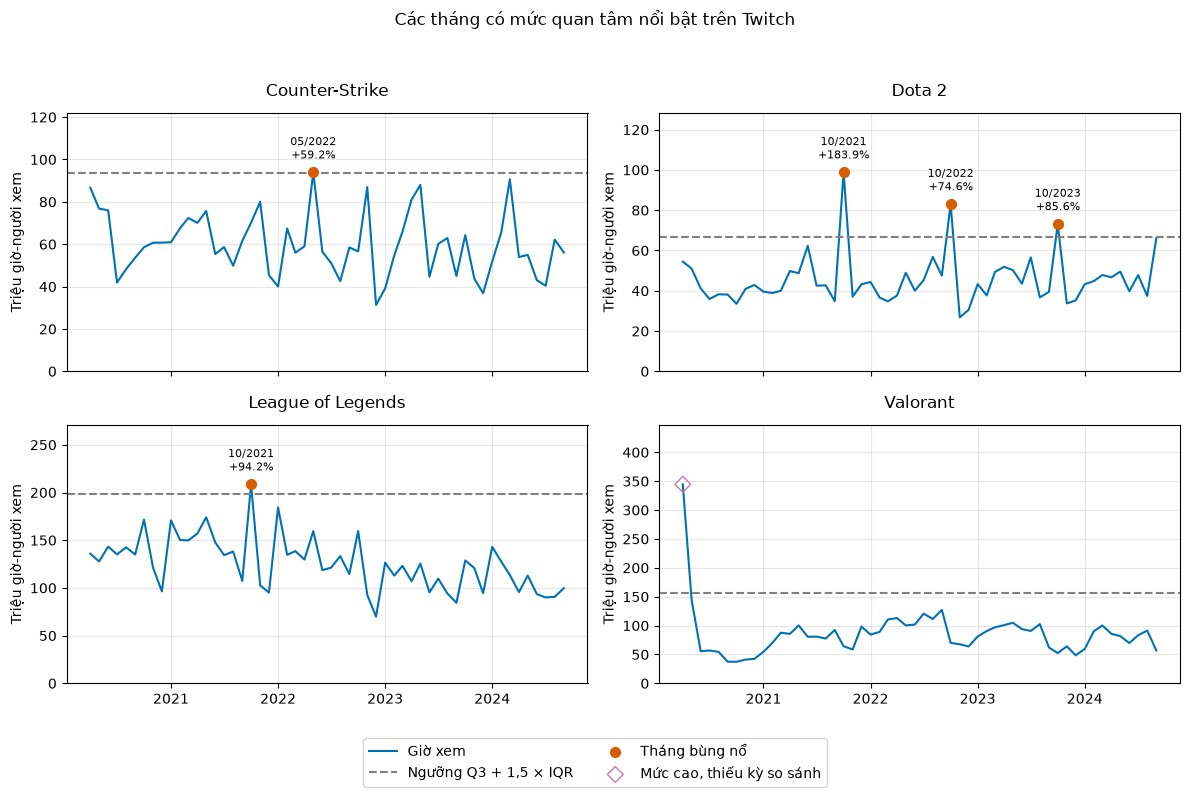

In [17]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]
fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)

for ax, game in zip(axes.flat, games):
    group = growth.loc[
        growth["game_family"].eq(game)
    ].sort_values("month_start")

    ax.plot(
        group["month_start"],
        group["hours_watched"] / 1_000_000,
        color="#0072B2",
        label="Giờ xem",
    )
    ax.axhline(
        group["upper_iqr"].iloc[0] / 1_000_000,
        color="gray", linestyle="--",
        label="Ngưỡng Q3 + 1,5 × IQR",
    )

    surge = group[group["surge_month"]]
    ax.scatter(
        surge["month_start"], surge["hours_watched"] / 1_000_000,
        color="#D55E00", s=50, zorder=3,
        label="Tháng bùng nổ",
    )

    for _, row in surge.iterrows():
        ax.annotate(
            f'{row["month_start"]:%m/%Y}\n'
            f'+{row["hours_watched_mom_pct"]:.1f}%',
            xy=(row["month_start"], row["hours_watched"] / 1_000_000),
            xytext=(0, 10), textcoords="offset points",
            ha="center", fontsize=8,
        )

     # Mức cao nhưng không có kỳ trước hợp lệ để tính tăng trưởng.
    no_previous = group[
        group["high_attention"]
        & group["hours_watched_mom_pct"].isna()
    ]
    ax.scatter(
        no_previous["month_start"],
        no_previous["hours_watched"] / 1_000_000,
        marker="D", facecolors="none", edgecolors="#CC79A7",
        s=65, zorder=3,
        label="Mức cao, thiếu kỳ so sánh",
    )

    ax.set_title(game)
    ax.set_ylabel("Triệu giờ-người xem")
    top = max(
        group["hours_watched"].max(),
        group["upper_iqr"].iloc[0],
    ) / 1_000_000

    ax.set_ylim(0, top * 1.30)
    ax.set_title(game, pad=12)
    ax.grid(alpha=0.3)
    ax.xaxis.set_major_locator(mdates.YearLocator())
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(
    handles, labels, loc="lower center",
    ncol=2, bbox_to_anchor=(0.5, 0),
)
fig.suptitle("Các tháng có mức quan tâm nổi bật trên Twitch")
fig.tight_layout(rect=[0, 0.09, 1, 0.95])
plt.show()

### Nạp bảng có mẫu số toàn Twitch

In [ ]:
panel = pd.read_csv(
    RELEASE_DIR / "game_monthly_panel.csv",
    encoding="utf-8-sig",
)
panel["month_start"] = pd.to_datetime(
    panel["month_start"], errors="raise"
)

share_data = panel.loc[
    panel["month_start"].between("2020-04-01", "2024-09-01")
].copy()

assert not share_data.duplicated(["game_family", "month_start"]).any()
assert share_data["twitch_platform_hours_watched"].notna().all()
assert share_data["twitch_platform_hours_watched"].gt(0).all()

share_data["share_pct"] = (
    share_data["hours_watched"]
    / share_data["twitch_platform_hours_watched"] * 100
)

assert share_data["share_pct"].between(0, 100).all()

### Vẽ tỷ trọng theo tháng

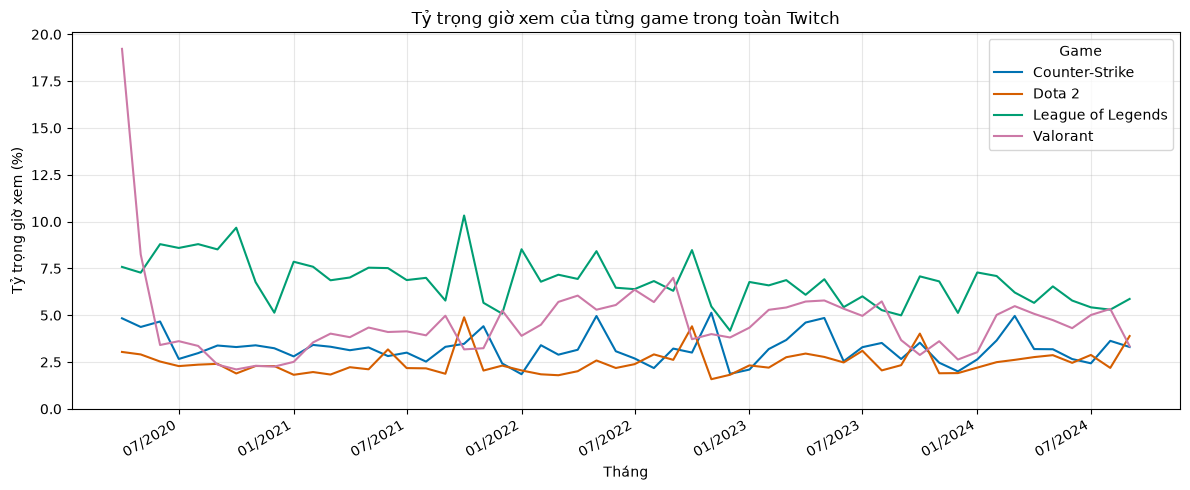

In [22]:
games = ["Counter-Strike", "Dota 2", "League of Legends", "Valorant"]
colors = dict(zip(
    games, ["#0072B2", "#D55E00", "#009E73", "#CC79A7"]
))

fig, ax = plt.subplots(figsize=(12, 5))

for game in games:
    group = share_data.loc[
        share_data["game_family"].eq(game)
    ].sort_values("month_start")

    ax.plot(
        group["month_start"], group["share_pct"],
        color=colors[game], label=game,
    )

ax.set_title("Tỷ trọng giờ xem của từng game trong toàn Twitch")
ax.set_xlabel("Tháng")
ax.set_ylabel("Tỷ trọng giờ xem (%)")
ax.set_ylim(bottom=0)
ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%m/%Y"))
ax.legend(title="Game")
ax.grid(alpha=0.3)

fig.autofmt_xdate()
fig.tight_layout()
plt.show()

### tỷ trọng trung vị theo tháng trong năm

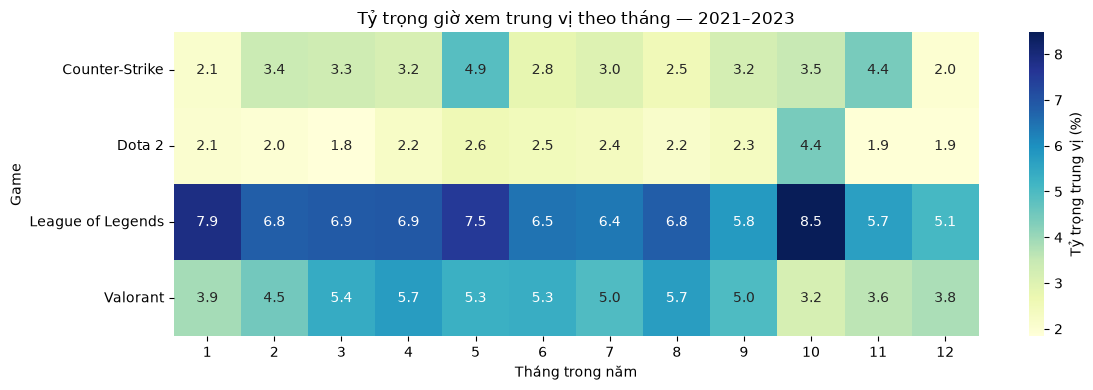

In [23]:
import seaborn as sns

seasonal = share_data.loc[
    share_data["month_start"].dt.year.between(2021, 2023)
].copy()

seasonal["month"] = seasonal["month_start"].dt.month

seasonal_table = (
    seasonal.groupby(["game_family", "month"])["share_pct"]
    .median()
    .unstack("month")
    .reindex(index=games, columns=range(1, 13))
)

fig, ax = plt.subplots(figsize=(12, 4))

sns.heatmap(
    seasonal_table,
    annot=True,
    fmt=".1f",
    cmap="YlGnBu",
    cbar_kws={"label": "Tỷ trọng trung vị (%)"},
    ax=ax,
)

ax.set_title("Tỷ trọng giờ xem trung vị theo tháng — 2021–2023")
ax.set_xlabel("Tháng trong năm")
ax.set_ylabel("Game")

fig.tight_layout()
plt.show()